# Simple Genetic Algorithm

The [Genetic Algorithm (GA)](https://www.wikiwand.com/en/Genetic_algorithm#Initialization) is a type of optimization algorithm inspired by the process of natural selection in biology. It is commonly used to solve problems that involve finding the best solution out of a large set of possible solutions, especially when the problem is complex and has many possible configurations.

The algorithm starts by generating an initial population of potential solutions, which are represented as a set of parameters or "genes". Each solution in the population is evaluated based on a fitness function that measures how well it performs the desired task. The best solutions are then selected for reproduction, which involves combining or "breeding" the genes of two or more solutions to create new offspring solutions. This process is repeated for multiple generations, with each successive generation being created by selecting and breeding the fittest solutions from the previous generation. The GA is inspired by biological evolution, and it simulates a process similar to natural selection in order to find a good solution to a problem

The GA has been used to solve a wide range of problems, including optimization, machine learning, and game theory. It is a powerful and versatile algorithm that can find high-quality solutions in complex and dynamic problem spaces.

The GA works through the following steps:

1. Initialization: Generate an initial population $P$ of $N$ individuals, each represented as a vector of genes. The population is typically chosen randomly or using heuristics.
2. Evaluation: Evaluate the fitness of each individual in $P$ using a fitness function $f(x_i)$, where $x_i$ is an individual in $P$.
3. Selection: Select a subset $S$ of the population for reproduction, based on their fitness. The selection can be done using various methods, such as roulette wheel selection, tournament selection, or rank-based selection.
4. Reproduction: Create a new population $P'$ of $N$ individuals by breeding the individuals in $S$. The breeding is typically done using genetic operators such as crossover and mutation, which introduce new genetic material into the population.
5. Replacement: Replace the old population $P$ with the new population $P'$. This step ensures that the population evolves over time and improves its fitness.
6. Termination: Terminate the algorithm if a stopping criterion is met, such as a maximum number of generations, a maximum fitness level, or a minimum improvement in fitness.
7. Output: The final solution is typically the fittest solution found in the last generation of the algorithm.

The GA can be modified and adapted to different problem domains by changing the specific genetic operators used, the fitness function, and the selection criteria. However, these six steps are the core of the algorithm and provide a general framework for solving optimization problems.

Resources:

- [Simple Genetic Algorithm From Scratch in Python](https://machinelearningmastery.com/simple-genetic-algorithm-from-scratch-in-python/)

## Genetic algorithm example

In the following example, the genetic algorithm is used to find the maximum sum of a binary vector, with a gene length of 5. The population size is 6, and the mutation rate and crossover rate are set to 0.1 and 0.8, respectively. Elitism is used, with an elite size of 6.

In [48]:
import numpy as np

# Define the fitness function to be maximized
def fitness_function(x):
    return np.sum(x)

### Define the parameters

In [49]:
# define the genetic algorithm parameters
POPULATION_SIZE = 6
GENE_LENGTH = 5
MUTATION_RATE = 1.0 / GENE_LENGTH
CROSSOVER_RATE = 0.8
ELITISM = True
ELITE_SIZE = 6
MAX_GENERATIONS = 5

### Following one iteration

In [50]:
population = np.random.randint(2, size=(POPULATION_SIZE, GENE_LENGTH))
print(population)

[[0 0 1 0 1]
 [0 1 0 0 0]
 [0 0 0 1 1]
 [1 1 1 1 1]
 [1 1 0 1 1]
 [0 1 0 1 1]]


In [51]:
fitness_values = np.apply_along_axis(fitness_function, 1, population)
print(fitness_values)

[2 1 2 5 4 3]


In the tournament strategy, an individual is randomly selected, to compete with a set of $k$ individuals (the tournament size) randomly selected. This operator requires a population of individuals, their corresponding fitness values, and $k$. It then loops through each individual in the population and performs the following steps:

1. Select a random subset of the population to form the tournament.
2. Calculate the fitness of each individual in the tournament.
3. Select the individual with the highest fitness in the tournament as the tournament winner.
4. Add the tournament winner to the selected individuals.

The selected individuals, can be used as the basis for the next generation of the genetic algorithm.

In [52]:
k = 3
num_individuals = population.shape[0]
num_genes = population.shape[1]

# Initialize selected individuals
parents = np.empty((num_individuals, num_genes), dtype=int)
parents_fitness = np.empty(num_individuals, dtype=int)

for i in range(num_individuals):
    # Select a random subset of the population to form the tournament
    tournament_indices = np.random.choice(num_individuals, k, replace=False)
    tournament_fitness = fitness_values[tournament_indices]

    # Select the individual with the highest fitness in the tournament
    tournament_winner_index = tournament_indices[np.argmax(tournament_fitness)]
    parents_fitness[i] = np.max(tournament_fitness)
    parents[i, :] = population[tournament_winner_index, :]
    
    print("-"*5)
    print("Tournament {}\n Indices in tournament: {} \n Fitness: {} \n Winner: {}" \
          .format(i+1, tournament_indices, tournament_fitness, parents[i, :]))

print("-"*5)
print('Selected individuals:\n{}'.format(parents))
print('Selected individuals fitness:\n{}'.format(parents_fitness))

-----
Tournament 1
 Indices in tournament: [1 4 5] 
 Fitness: [1 4 3] 
 Winner: [1 1 0 1 1]
-----
Tournament 2
 Indices in tournament: [1 2 4] 
 Fitness: [1 2 4] 
 Winner: [1 1 0 1 1]
-----
Tournament 3
 Indices in tournament: [0 5 1] 
 Fitness: [2 3 1] 
 Winner: [0 1 0 1 1]
-----
Tournament 4
 Indices in tournament: [3 2 4] 
 Fitness: [5 2 4] 
 Winner: [1 1 1 1 1]
-----
Tournament 5
 Indices in tournament: [5 3 2] 
 Fitness: [3 5 2] 
 Winner: [1 1 1 1 1]
-----
Tournament 6
 Indices in tournament: [1 0 5] 
 Fitness: [1 2 3] 
 Winner: [0 1 0 1 1]
-----
Selected individuals:
[[1 1 0 1 1]
 [1 1 0 1 1]
 [0 1 0 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 1 0 1 1]]
Selected individuals fitness:
[4 4 3 5 5 3]


In [53]:
num_parents = parents.shape[0]
num_genes = parents.shape[1]

# Initialize offspring array
offspring = np.empty((num_parents, num_genes), dtype=int)

for i in range(0, num_parents, 2):
    if np.random.rand() < CROSSOVER_RATE:
        # Select crossover point at random
        crossover_point = np.random.randint(1, num_genes)
        
        # Perform single-point crossover
        offspring[i, :crossover_point] = parents[i, :crossover_point]
        offspring[i, crossover_point:] = parents[i+1, crossover_point:]
        offspring[i+1, :crossover_point] = parents[i+1, :crossover_point]
        offspring[i+1, crossover_point:] = parents[i, crossover_point:]
        
        print("-"*5)
        print("Parents: {}, {} \n Offspring: {}, {} \n Crossover point: {}" \
          .format(parents[i, :], parents[i+1, :], offspring[i, :], offspring[i+1, :], crossover_point))
    else:
        # If no crossover is performed, simply copy parents to offspring
        offspring[i, :] = parents[i, :]
        offspring[i+1, :] = parents[i+1, :]
        print("-"*5)
        print("Parents: {}, {} \n Offspring: {}, {}" \
          .format(parents[i, :], parents[i+1, :], offspring[i, :], offspring[i+1, :]))

print("-"*5)
print('Offspring:\n{}'.format(offspring))
    

-----
Parents: [1 1 0 1 1], [1 1 0 1 1] 
 Offspring: [1 1 0 1 1], [1 1 0 1 1] 
 Crossover point: 4
-----
Parents: [0 1 0 1 1], [1 1 1 1 1] 
 Offspring: [0 1 0 1 1], [1 1 1 1 1] 
 Crossover point: 4
-----
Parents: [1 1 1 1 1], [0 1 0 1 1] 
 Offspring: [1 1 1 1 1], [0 1 0 1 1]
-----
Offspring:
[[1 1 0 1 1]
 [1 1 0 1 1]
 [0 1 0 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 1 0 1 1]]


In [54]:
mask = np.random.rand(*offspring.shape) < MUTATION_RATE
offspring[mask] = 1 - offspring[mask]
print('Mutated offspring:\n{}'.format(offspring))
offspring_fitness = evaluate_population(offspring)
print('Mutated offspring fitness:{}'.format(offspring_fitness))

Mutated offspring:
[[1 1 1 1 1]
 [0 1 0 1 0]
 [1 1 0 1 1]
 [1 0 1 1 1]
 [0 1 1 1 0]
 [0 1 0 0 1]]
Mutated offspring fitness:[5 2 4 4 3 2]


In [55]:
population = np.vstack((parents, offspring))
fitness_values = np.concatenate((parents_fitness, offspring_fitness))
print('Indivituals for elitism selection:\n{}'.format(population))
print('Indivituals fitness for elitism selection:\n{}'.format(fitness_values))

elite_indices = np.argsort(fitness_values)[:ELITE_SIZE-1:-1]
print('Elite indices:\n{}'.format(elite_indices))
elites = population[elite_indices, :]
print('Elite:\n{}'.format(elites))

Indivituals for elitism selection:
[[1 1 0 1 1]
 [1 1 0 1 1]
 [0 1 0 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 1 0 1 1]
 [1 1 1 1 1]
 [0 1 0 1 0]
 [1 1 0 1 1]
 [1 0 1 1 1]
 [0 1 1 1 0]
 [0 1 0 0 1]]
Indivituals fitness for elitism selection:
[4 4 3 5 5 3 5 2 4 4 3 2]
Elite indices:
[6 4 3 9 8 1]
Elite:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 0 1 1 1]
 [1 1 0 1 1]
 [1 1 0 1 1]]


### Run the genetic algorithm and print the best solution found

In [56]:
# best_solution = run_genetic_algorithm(POPULATION_SIZE, 
#                                       GENE_LENGTH, 
#                                       MAX_GENERATIONS, 
#                                       CROSSOVER_RATE, 
#                                       MUTATION_RATE, ELITISM, 
#                                       ELITE_SIZE)

# print("Best Solution: {}".format(best_solution))

In [57]:
# define the fitness function to be maximized
def fitness_function(x):
    # define your fitness function here
    return x[0]**2 + x[1]**2

In [58]:
# define range for input
BOUNDS = [[-5.0, 5.0], [-5.0, 5.0]]

# define the genetic algorithm parameters
POPULATION_SIZE = 6
GENE_LENGTH = 16
MUTATION_RATE = 1.0 / (float(GENE_LENGTH) * len(BOUNDS))
CROSSOVER_RATE = 0.8
ELITISM = True
ELITE_SIZE = 6
MAX_GENERATIONS = 5

In [59]:
population = np.random.randint(2, size=(POPULATION_SIZE, GENE_LENGTH*len(BOUNDS)))
print(population)

[[1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 1 1 0 0 1 0]
 [0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 1]
 [1 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 1 1 1 0 0]
 [1 1 1 1 0 0 0 0 1 1 0 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 0 0]
 [0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 1]
 [0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1]]


In [33]:
fitness_function([0, 0])

0

In [41]:
import numpy as np

# define the genetic algorithm parameters
POPULATION_SIZE = 100
GENE_LENGTH = 10
MUTATION_RATE = 0.1
CROSSOVER_RATE = 0.8
ELITISM = True
ELITE_SIZE = 2
MAX_GENERATIONS = 10

# define the fitness function to be maximized
def fitness_function(x):
    # define your fitness function here
    return x[0]**2 + x[1]**2

# initialize the population with random genes
def initialize_population():
    return np.random.uniform(low=-5.0, high=5.0, size=(POPULATION_SIZE, GENE_LENGTH))

# evaluate the fitness of each individual in the population
def evaluate_population(population):
    fitness_values = np.apply_along_axis(fitness_function, 1, population)
    return fitness_values

# select parents using tournament selection
def tournament_selection(population, fitness_values, k=2):
    indices = np.random.randint(0, population.shape[0], (k, len(population)))
    selected_indices = np.argmax(fitness_values[indices], axis=0)
    return population[indices[selected_indices, np.arange(len(population))]]

# perform crossover on selected parents
def crossover(parents):
    children = parents.copy()
    mask = np.random.randint(0, 2, size=parents.shape[1], dtype=bool)
    children[0, mask] = parents[1, mask]
    children[1, mask] = parents[0, mask]
    return children

# perform mutation on the population
def mutate(population):
    mask = np.random.rand(*population.shape) < MUTATION_RATE
    population[mask] += np.random.normal(scale=0.1, size=population[mask].shape)
    return population

# select the next generation using elitism and tournament selection
def select_next_generation(population, fitness_values):
    if ELITISM:
        elite_indices = np.argsort(fitness_values)[-ELITE_SIZE:]
        elite_population = population[elite_indices]
        population = tournament_selection(population, fitness_values)
        population[-ELITE_SIZE:] = elite_population
    else:
        population = tournament_selection(population, fitness_values)
    return population

# run the genetic algorithm to find the optimal solution
def run_genetic_algorithm():
    # initialize the population and fitness values
    population = initialize_population()
    fitness_values = evaluate_population(population)

    for generation in range(MAX_GENERATIONS):
        # select parents and perform crossover
        parents = tournament_selection(population, fitness_values, k=2)
        children = crossover(parents)

        # mutate the children and evaluate the fitness of the new population
        children = mutate(children)
        children_fitness = evaluate_population(children)

        # select the next generation
        population = select_next_generation(np.vstack((population, children)), np.concatenate((fitness_values, children_fitness)))
        fitness_values = evaluate_population(population)

        # print the best fitness value for this generation
        print("Generation {}: Best Fitness = {}".format(generation, np.max(fitness_values)))

    # return the best solution found
    best_index = np.argmax(fitness_values)
    return population[best_index]

# run the genetic algorithm and print the best solution found
best_solution = run_genetic_algorithm()
print("Best Solution: {}".format(best_solution))


Generation 0: Best Fitness = 47.059515636375394
Generation 1: Best Fitness = 47.889385967480294
Generation 2: Best Fitness = 48.284602665054045
Generation 3: Best Fitness = 49.47035408635894
Generation 4: Best Fitness = 50.73471279134344
Generation 5: Best Fitness = 51.94003795187149
Generation 6: Best Fitness = 51.94003795187149
Generation 7: Best Fitness = 55.58698917598347
Generation 8: Best Fitness = 55.58698917598347
Generation 9: Best Fitness = 55.87925963839109
Best Solution: [ 5.16213624 -5.40662641  3.72058    -2.89690443 -1.05069466  1.70237221
  4.68506709 -1.4839917  -2.68351999  3.34059492]


In [44]:

fitness_function([0, 0])

2

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pygad

In [15]:
def ackley(x):
    x1 = x[0]
    x2 = x[1]
    A = np.exp(-0.2 * np.sqrt(0.5 * (x1**2 + x2**2)))
    B = np.exp(0.5 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2)))
    return -20.0 * A - B + np.exp(1) + 20

def fitness_func(solution, solution_idx):
    fitness = 1.0 / (ackley(solution) + 1e-8)
    return fitness

In [16]:
# Define the bounds for the input variables
bounds = np.array([[-5, 5], [-5, 5]])

In [23]:
# # Create an instance of the pygad.GA class
# ga_instance = pygad.GA(
#     num_generations=100,
#     fitness_func=fitness_func,
#     num_parents_mating=2,
#     initial_population=([2, 3], [4, 3]),
# )

Generation = 1
Fitness    = 1.915084428939083
Change     = 1.915084428939083
Generation = 2
Fitness    = 1.915084428939083
Change     = 0.0
Generation = 3
Fitness    = 1.915084428939083
Change     = 0.0
Generation = 4
Fitness    = 1.915084428939083
Change     = 0.0
Generation = 5
Fitness    = 1.915084428939083
Change     = 0.0
Generation = 6
Fitness    = 14.282230123008738
Change     = 12.367145694069654
Generation = 7
Fitness    = 14.282230123008738
Change     = 0.0
Generation = 8
Fitness    = 19.10488528628459
Change     = 4.822655163275851
Generation = 9
Fitness    = 19.10488528628459
Change     = 0.0
Generation = 10
Fitness    = 1723.1082665743577
Change     = 1704.0033812880731
Generation = 11
Fitness    = 1723.1082665743577
Change     = 0.0
Generation = 12
Fitness    = 1723.1082665743577
Change     = 0.0
Generation = 13
Fitness    = 1723.1082665743577
Change     = 0.0
Generation = 14
Fitness    = 1723.1082665743577
Change     = 0.0
Generation = 15
Fitness    = 1723.1082665743577


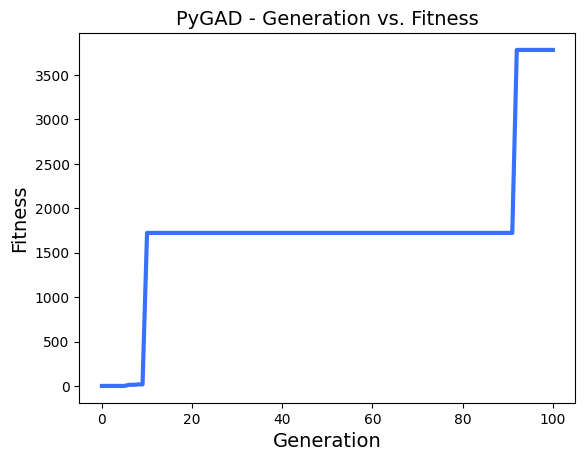

Parameters of the best solution : [-0.68588165 -2.07246156  0.15873666  2.21486595 -1.39455557 -3.32517461]
Fitness value of the best solution = 3781.15612102768
Index of the best solution : 0
Predicted output based on the best solution : 43.99973653062397
Best fitness value reached after 92 generations.


In [24]:
import pygad
import numpy

"""
Given the following function:
    y = f(w1:w6) = w1x1 + w2x2 + w3x3 + w4x4 + w5x5 + 6wx6
    where (x1,x2,x3,x4,x5,x6)=(4,-2,3.5,5,-11,-4.7) and y=44
What are the best values for the 6 weights (w1 to w6)? We are going to use the genetic algorithm to optimize this function.
"""

function_inputs = [4,-2,3.5,5,-11,-4.7] # Function inputs.
desired_output = 44 # Function output.

def fitness_func(ga_instance, solution, solution_idx):
    output = numpy.sum(solution*function_inputs)
    fitness = 1.0 / (numpy.abs(output - desired_output) + 0.000001)
    return fitness

num_generations = 100 # Number of generations.
num_parents_mating = 10 # Number of solutions to be selected as parents in the mating pool.

sol_per_pop = 20 # Number of solutions in the population.
num_genes = len(function_inputs)

last_fitness = 0
def on_generation(ga_instance):
    global last_fitness
    print("Generation = {generation}".format(generation=ga_instance.generations_completed))
    print("Fitness    = {fitness}".format(fitness=ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]))
    print("Change     = {change}".format(change=ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1] - last_fitness))
    last_fitness = ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       fitness_func=fitness_func,
                       on_generation=on_generation)

# Running the GA to optimize the parameters of the function.
ga_instance.run()

ga_instance.plot_fitness()

# Returning the details of the best solution.
solution, solution_fitness, solution_idx = ga_instance.best_solution(ga_instance.last_generation_fitness)
print("Parameters of the best solution : {solution}".format(solution=solution))
print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))
print("Index of the best solution : {solution_idx}".format(solution_idx=solution_idx))

prediction = numpy.sum(numpy.array(function_inputs)*solution)
print("Predicted output based on the best solution : {prediction}".format(prediction=prediction))

if ga_instance.best_solution_generation != -1:
    print("Best fitness value reached after {best_solution_generation} generations.".format(best_solution_generation=ga_instance.best_solution_generation))

# Saving the GA instance.
# filename = 'genetic' # The filename to which the instance is saved. The name is without extension.
# ga_instance.save(filename=filename)

# # Loading the saved GA instance.
# loaded_ga_instance = pygad.load(filename=filename)
# loaded_ga_instance.plot_fitness()